# 04_modelo — Previsão de Churn

Treina, avalia e aplica o modelo de previsão de churn com horizonte de 3 meses.

**Input:** `data/processed/df_model.parquet`
**Output:** `data/processed/scores_2026.parquet`, modelo salvo em `data/processed/modelo_churn.pkl`

---
## Seção 1 — Setup

In [1]:

import sys, os, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

PROJECT_ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.config import PROCESSED_DIR, VERDE

print("Setup OK")
print("Working directory:", os.getcwd())

Setup OK
Working directory: c:\Users\carva\OneDrive\Área de Trabalho\central_eto


In [2]:
df_treino = pd.read_parquet(PROCESSED_DIR / "df_model_treino.parquet")
df_teste  = pd.read_parquet(PROCESSED_DIR / "df_model_teste.parquet")

print(f"Treino : {df_treino.shape}  |  churn: {df_treino['churn'].mean():.1%}")
print(f"Teste  : {df_teste.shape}   |  churn: {df_teste['churn'].mean():.1%}")

Treino : (610, 23)  |  churn: 36.2%
Teste  : (724, 23)   |  churn: 49.0%


In [3]:
print("=== Treino ===")
print(df_treino["churn"].value_counts().rename({0: "Ativo", 1: "Churnou"}))
print(f"Missing: {df_treino.isna().sum().sum()}")

print("\n=== Teste ===")
print(df_teste["churn"].value_counts().rename({0: "Ativo", 1: "Churnou"}))
print(f"Missing: {df_teste.isna().sum().sum()}")

=== Treino ===
churn
Ativo      389
Churnou    221
Name: count, dtype: int64
Missing: 0

=== Teste ===
churn
Ativo      369
Churnou    355
Name: count, dtype: int64
Missing: 0


In [4]:
# CORRIGIDO (jul/2026, Passo 2): preparar_xy() extraída para src/model_prep.py —
# reutilizável por scripts/scoring_mensal.py, explicar_cliente.py e
# notebooks/explicar_cliente.ipynb, evitando divergência entre eles.
from src.model_prep import preparar_xy, IDENTIFICADORES, TARGET, MAPA_CATEGORIA, FILLNA_SEMANTICO

X_train, y_train = preparar_xy(df_treino)
X_test,  y_test  = preparar_xy(df_teste)

print(f"X_train: {X_train.shape}  |  churn: {y_train.mean():.1%}  |  NaN: {X_train.isna().sum().sum()}")
print(f"X_test : {X_test.shape}   |  churn: {y_test.mean():.1%}  |  NaN: {X_test.isna().sum().sum()}")

X_train: (610, 20)  |  churn: 36.2%  |  NaN: 0


X_test : (724, 20)   |  churn: 49.0%  |  NaN: 0


---
## Split temporal

Treino e teste são snapshots em pontos diferentes no tempo — sem split aleatório.

| Conjunto | CUTOFF | Features | Outcome |
|---|---|---|---|
| Treino | dez/2024 | jan/23–dez/24 | churn em 2025 (janela por categoria) |
| Teste  | dez/2025 | jan/23–dez/25 | churn em 2026 (janela por categoria, travada em mai/26) |

In [5]:
# X_train, y_train e X_test, y_test já foram definidos na célula anterior
# com base nos dois parquets de treino e teste

print(f"Treino : {X_train.shape[0]} clientes  |  churn: {y_train.mean():.1%}")
print(f"Teste  : {X_test.shape[0]} clientes   |  churn: {y_test.mean():.1%}")

Treino : 610 clientes  |  churn: 36.2%
Teste  : 724 clientes   |  churn: 49.0%


---
## Seção 2 — EDA da Modelagem

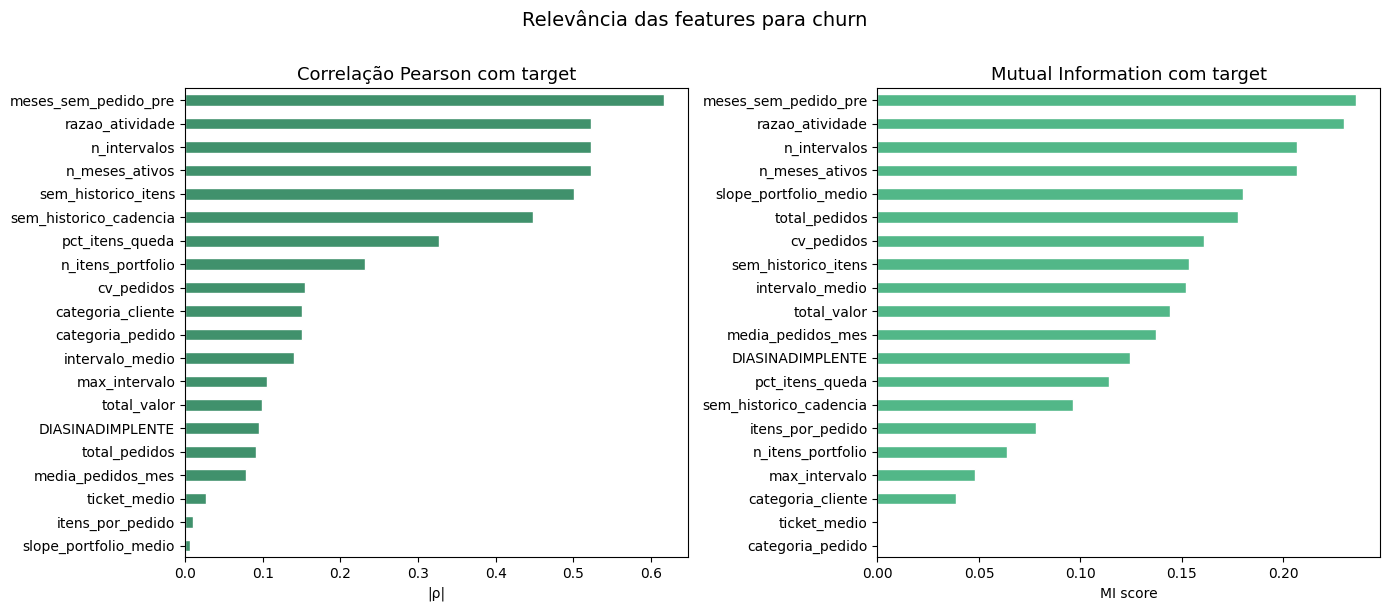

                        pearson  mutual_info
meses_sem_pedido_pre      0.616        0.236
razao_atividade           0.523        0.230
n_meses_ativos            0.523        0.207
n_intervalos              0.523        0.207
sem_historico_itens       0.500        0.153
sem_historico_cadencia    0.448        0.096
pct_itens_queda           0.327        0.114
n_itens_portfolio         0.232        0.064
cv_pedidos                0.155        0.161
categoria_pedido          0.151        0.000
categoria_cliente         0.151        0.039
intervalo_medio           0.141        0.152
max_intervalo             0.106        0.048
total_valor               0.099        0.144
DIASINADIMPLENTE          0.096        0.125
total_pedidos             0.092        0.178
media_pedidos_mes         0.079        0.137
ticket_medio              0.027        0.000
itens_por_pedido          0.011        0.078
slope_portfolio_medio     0.007        0.180


In [6]:
from sklearn.feature_selection import mutual_info_classif

X_num = X_train.select_dtypes(include="number")
pearson = X_num.corrwith(y_train).abs().sort_values(ascending=False).rename("pearson")

mi_scores = mutual_info_classif(X_num.fillna(0), y_train, random_state=42)
mi = pd.Series(mi_scores, index=X_num.columns).sort_values(ascending=False).rename("mutual_info")

corr_target = pd.concat([pearson, mi], axis=1).sort_values("pearson", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_target["pearson"].sort_values().plot(
    kind="barh", ax=axes[0], color=VERDE[5], edgecolor="white"
)
axes[0].set_title("Correlação Pearson com target", fontsize=13)
axes[0].set_xlabel("|ρ|")

corr_target["mutual_info"].sort_values().plot(
    kind="barh", ax=axes[1], color=VERDE[4], edgecolor="white"
)
axes[1].set_title("Mutual Information com target", fontsize=13)
axes[1].set_xlabel("MI score")

plt.suptitle("Relevância das features para churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(corr_target.round(3).to_string())

In [7]:
# === Análise exploratória: sinal com o target ===
# Identifica features com Pearson E MI abaixo do threshold.
# ATENÇÃO: isso é uma hipótese de remoção, não uma decisão final.
# Features fracas individualmente podem contribuir via interações no XGBoost.
# A decisão definitiva de remoção virá do SHAP (Seção 9).

PEARSON_MIN = 0.10
MI_MIN      = 0.05

baixo_sinal = corr_target[
    (corr_target["pearson"]     < PEARSON_MIN) &
    (corr_target["mutual_info"] < MI_MIN)
].sort_values("pearson")

print(f"Features com Pearson < {PEARSON_MIN} E MI < {MI_MIN} (hipóteses de remoção):\n")
print(f"{'Feature':<25} {'Pearson':>8}  {'MI':>8}")
print("-" * 45)
for feat, row in baixo_sinal.iterrows():
    print(f"{feat:<25} {row['pearson']:>8.3f}  {row['mutual_info']:>8.3f}")

HIPOTESES_BAIXO_SINAL = baixo_sinal.index.tolist()
print(f"\n→ {len(HIPOTESES_BAIXO_SINAL)} hipóteses: {HIPOTESES_BAIXO_SINAL}")
print("→ Confirmar ou descartar via SHAP na Seção 9.")

Features com Pearson < 0.1 E MI < 0.05 (hipóteses de remoção):

Feature                    Pearson        MI
---------------------------------------------
ticket_medio                 0.027     0.000

→ 1 hipóteses: ['ticket_medio']
→ Confirmar ou descartar via SHAP na Seção 9.


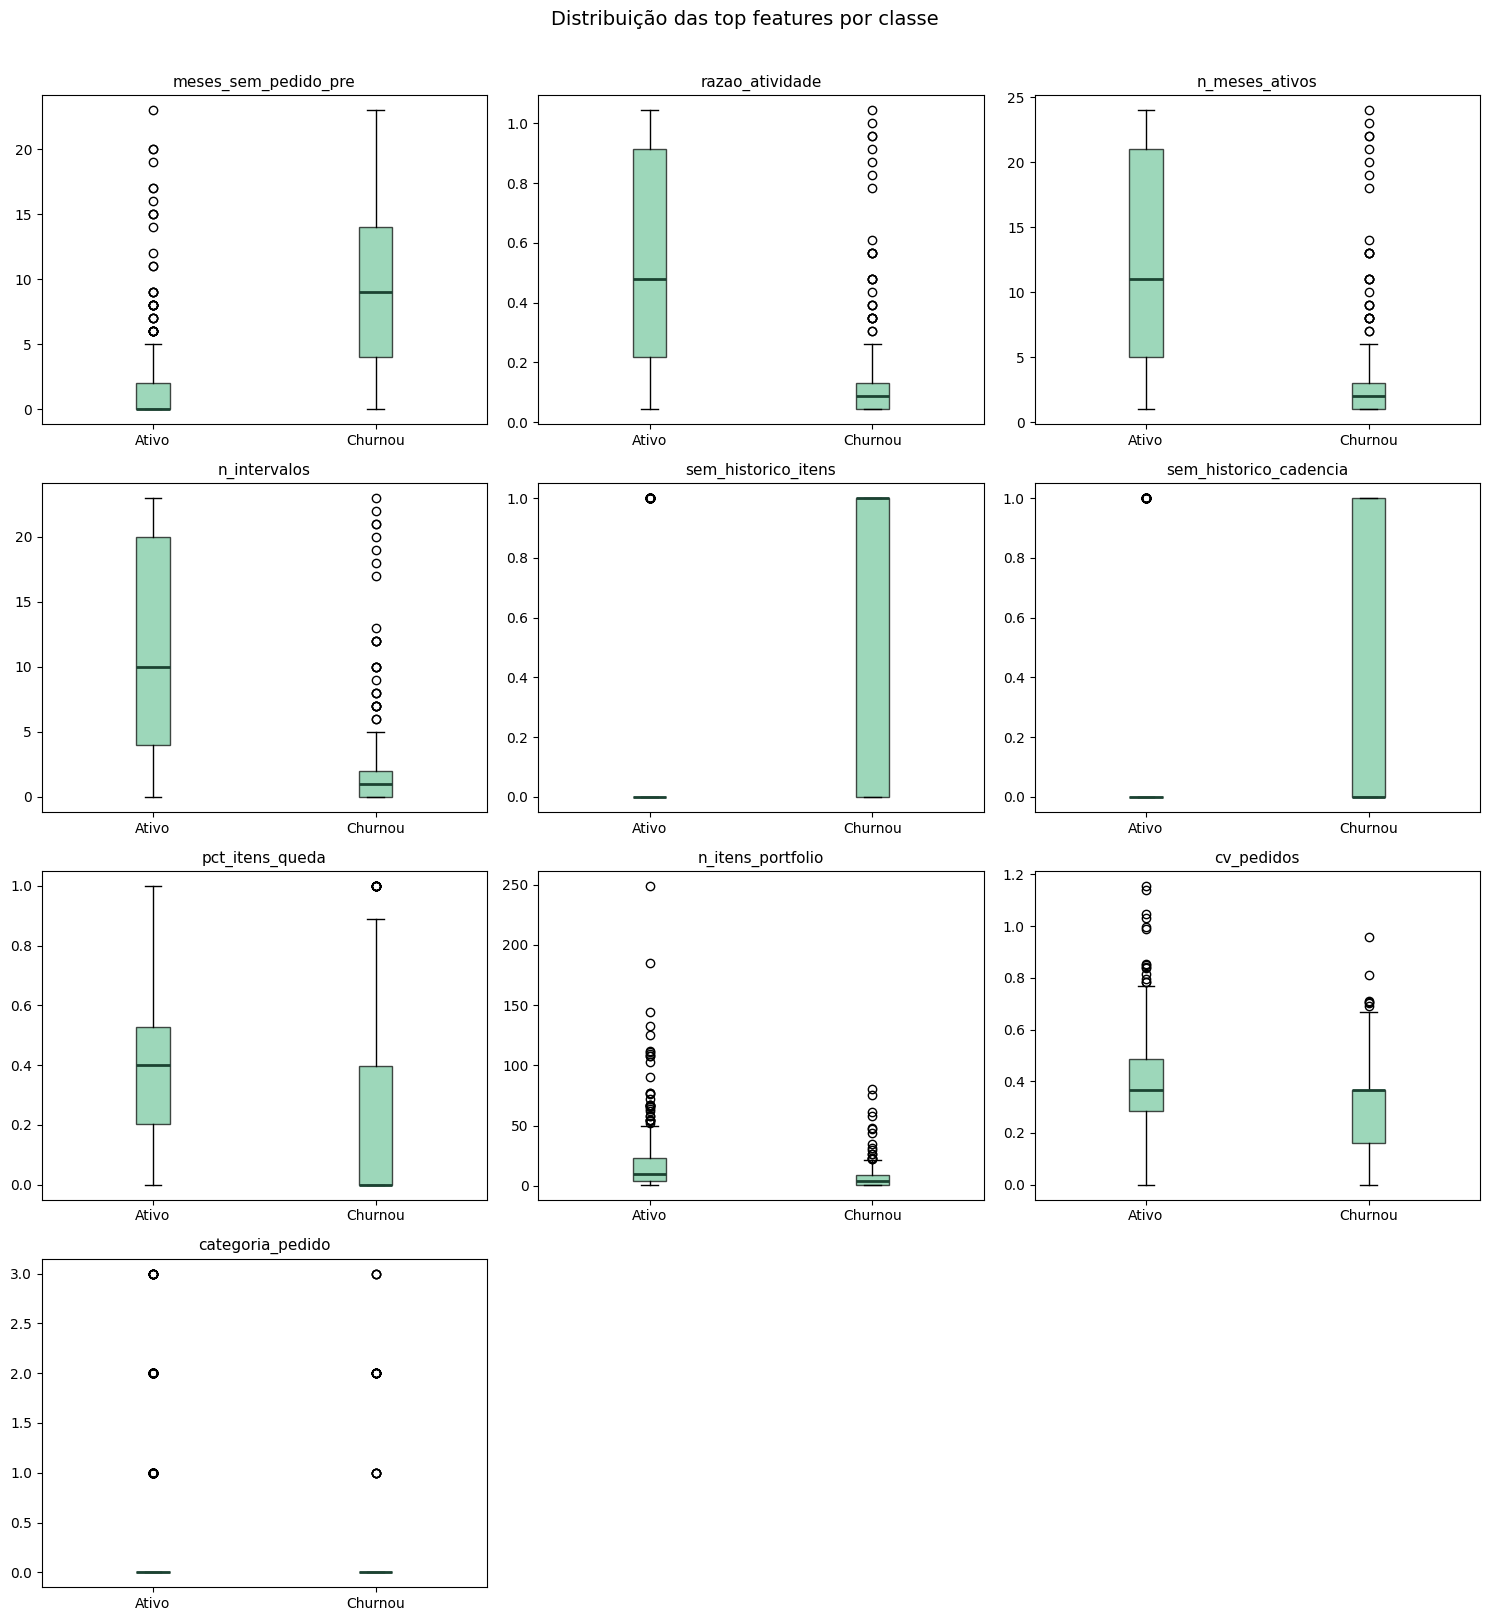

In [8]:
top_features = corr_target["pearson"].sort_values(ascending=False).head(10).index.tolist()

df_plot = X_train[top_features].copy()
df_plot["churn"] = y_train.values

n_cols = 3
n_rows = -(-len(top_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    grupos = [df_plot.loc[df_plot["churn"] == 0, feat], df_plot.loc[df_plot["churn"] == 1, feat]]
    axes[i].boxplot(grupos, labels=["Ativo", "Churnou"], patch_artist=True,
                    boxprops=dict(facecolor=VERDE[3], alpha=0.7),
                    medianprops=dict(color=VERDE[7], linewidth=2))
    axes[i].set_title(feat, fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das top features por classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

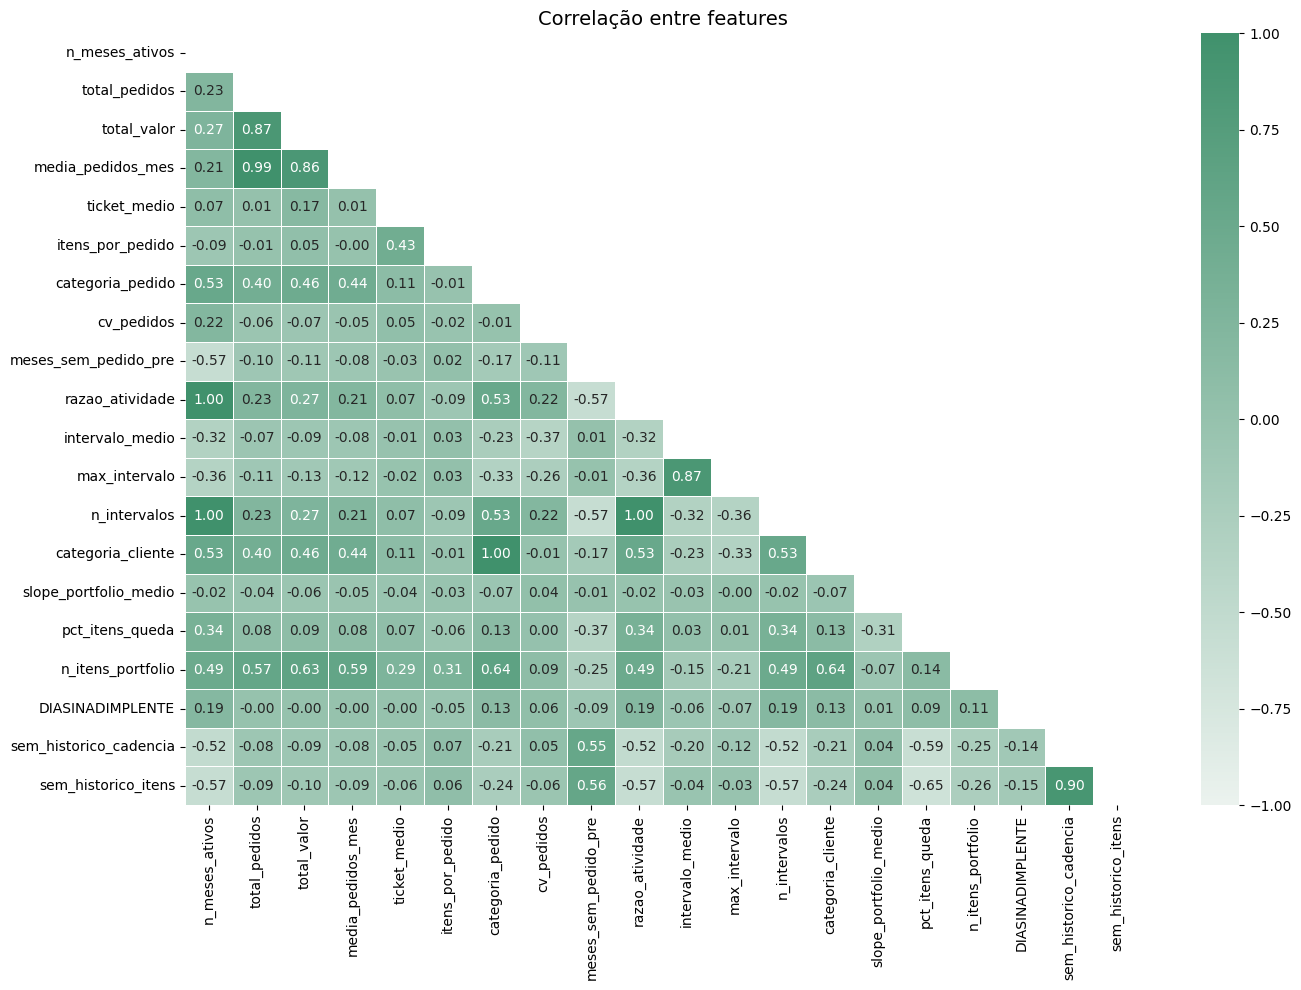

Pares com correlação > 0.7:
             feat_a                 feat_b     corr
    razao_atividade         n_meses_ativos 1.000000
       n_intervalos        razao_atividade 1.000000
  categoria_cliente       categoria_pedido 1.000000
       n_intervalos         n_meses_ativos 1.000000
  media_pedidos_mes          total_pedidos 0.994685
sem_historico_itens sem_historico_cadencia 0.902132
      max_intervalo        intervalo_medio 0.871391
        total_valor          total_pedidos 0.867461
  media_pedidos_mes            total_valor 0.862993


In [9]:
import seaborn as sns

corr_matrix = X_train.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=sns.light_palette(VERDE[5], as_cmap=True),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1,
    center=0,
)
ax.set_title("Correlação entre features", fontsize=14)
plt.tight_layout()
plt.show()

alta_corr = (
    corr_matrix.abs()
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "corr"})
    .query("corr > 0.7")
    .sort_values("corr", ascending=False)
)

if alta_corr.empty:
    print("Nenhum par com correlação > 0.7")
else:
    print("Pares com correlação > 0.7:")
    print(alta_corr.to_string(index=False))

---
## Seção 3 — Análise Exploratória de Features

Identifica **hipóteses** de remoção por dois critérios independentes:
1. **Alta correlação entre features** → uma delas é redundante
2. *(já feito na Seção 2)* Baixo sinal com o target (Pearson + MI)

Estas listas **não são filtros definitivos** — features com sinal fraco individualmente podem contribuir via interações no XGBoost. A decisão final de remoção virá do SHAP (Seção 9).

**Exceção:** `razao_atividade` é transformação linear de `n_meses_ativos` (divisão por constante) — remoção garantida independente do modelo.

In [10]:
CORR_THRESHOLD = 0.80

# Score combinado normalizado: Pearson + MI, cada um escalado para [0, 1]
score_target = corr_target.assign(
    p_norm = lambda d: d["pearson"]     / d["pearson"].max(),
    m_norm = lambda d: d["mutual_info"] / d["mutual_info"].max(),
    score  = lambda d: d["p_norm"] + d["m_norm"],
)["score"]

# Correlação entre features (fillna=0 apenas para o cálculo da matriz)
X_num   = X_train.select_dtypes(include="number")
corr_ff = X_num.fillna(0).corr().abs()

pares = (
    corr_ff
    .where(np.tril(np.ones(corr_ff.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "corr_ff"})
    .query("corr_ff > @CORR_THRESHOLD")
    .sort_values("corr_ff", ascending=False)
    .reset_index(drop=True)
)

rows = []
for _, r in pares.iterrows():
    a, b   = r["feat_a"], r["feat_b"]
    sa, sb = score_target.get(a, 0), score_target.get(b, 0)
    remover, manter = (a, b) if sa <= sb else (b, a)
    rows.append({
        "remover":       remover,
        "manter":        manter,
        "corr_entre_si": round(r["corr_ff"], 3),
        "score_remover": round(score_target.get(remover, 0), 3),
        "score_manter":  round(score_target.get(manter,  0), 3),
    })

df_hipoteses_corr = (
    pd.DataFrame(rows)
    .drop_duplicates(subset="remover")
    .reset_index(drop=True)
)

print(f"Hipóteses por alta correlação entre features (threshold: {CORR_THRESHOLD}):\n")
print(f"{'REMOVER':<25} {'MANTER':<25} {'corr':>6}  {'sc_rem':>6}  {'sc_man':>6}")
print("=" * 65)
for _, r in df_hipoteses_corr.iterrows():
    print(f"{r['remover']:<25} {r['manter']:<25} {r['corr_entre_si']:>6.3f}  {r['score_remover']:>6.3f}  {r['score_manter']:>6.3f}")

HIPOTESES_REDUNDANCIA = df_hipoteses_corr["remover"].tolist()
print(f"\n→ {len(HIPOTESES_REDUNDANCIA)} hipóteses: {HIPOTESES_REDUNDANCIA}")
print("→ Confirmar ou descartar via SHAP na Seção 9.")
print("→ Exceção: 'razao_atividade' será removida agora (transformação linear de n_meses_ativos).")

# Remoção garantida — transformação linear, zero informação nova
REMOVER_AGORA = ["razao_atividade"]
X_train_clean = X_train.drop(columns=REMOVER_AGORA, errors="ignore")
X_test_clean  = X_test.drop(columns=REMOVER_AGORA, errors="ignore")
print(f"\nX_train após remoção garantida: {X_train_clean.shape}")

Hipóteses por alta correlação entre features (threshold: 0.8):

REMOVER                   MANTER                      corr  sc_rem  sc_man
n_meses_ativos            razao_atividade            1.000   1.724   1.823
n_intervalos              razao_atividade            1.000   1.726   1.823
categoria_pedido          categoria_cliente          1.000   0.245   0.409
media_pedidos_mes         total_pedidos              0.995   0.710   0.902
sem_historico_cadencia    sem_historico_itens        0.902   1.137   1.462
max_intervalo             intervalo_medio            0.871   0.375   0.872
total_valor               total_pedidos              0.867   0.771   0.902

→ 7 hipóteses: ['n_meses_ativos', 'n_intervalos', 'categoria_pedido', 'media_pedidos_mes', 'sem_historico_cadencia', 'max_intervalo', 'total_valor']
→ Confirmar ou descartar via SHAP na Seção 9.
→ Exceção: 'razao_atividade' será removida agora (transformação linear de n_meses_ativos).

X_train após remoção garantida: (610, 19)


---
## Seção 4 — Distribuição de Classes

Verificar se o imbalanceamento exige intervenção antes da modelagem.

| Situação | Decisão |
|---|---|
| Imbalanceamento severo (< 10% positivos) | SMOTE ou `scale_pos_weight` obrigatório |
| Imbalanceamento moderado (10–30%) | `scale_pos_weight` recomendado |
| Balanceamento razoável (> 30%) | Sem intervenção — threshold resolve |

`scale_pos_weight` não será aplicado como pré-processamento fixo: entra como **hiperparâmetro no Optuna** (Seção 8) para que a validação cruzada decida se ajuda.

O shift de distribuição entre treino (36%) e teste (49%) é real mas não é imbalanceamento — é reflexo de um período com mais clientes novos e voláteis. Tratado por **calibração de threshold no conjunto de teste** (Seção 7).

Treino — Ativo (0): 389  |  Churnou (1): 221  |  Taxa churn: 36.2%
scale_pos_weight referência (n_neg / n_pos): 1.76


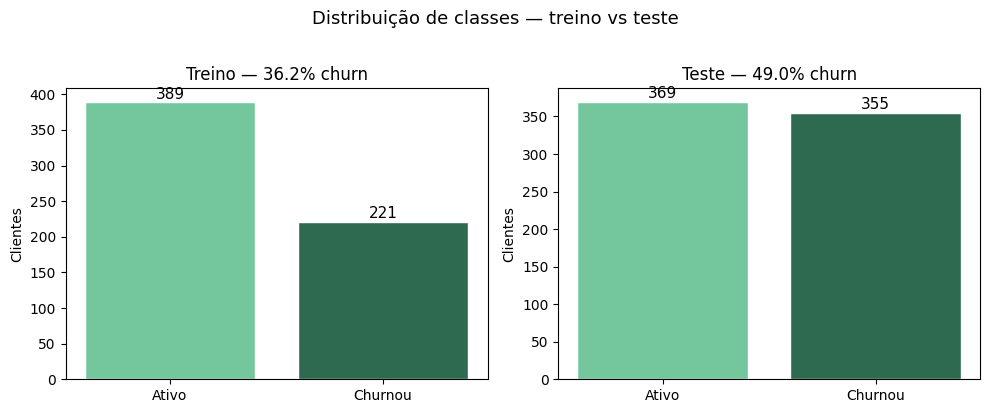


✓ Balanceamento razoável (> 30%) — sem intervenção obrigatória.
  scale_pos_weight tratado como hiperparâmetro no Optuna (Seção 8).


In [11]:
n_pos   = y_train.sum()
n_neg   = (y_train == 0).sum()
pct_pos = y_train.mean()

print(f"Treino — Ativo (0): {n_neg}  |  Churnou (1): {n_pos}  |  Taxa churn: {pct_pos:.1%}")
print(f"scale_pos_weight referência (n_neg / n_pos): {n_neg / n_pos:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Treino
axes[0].bar(["Ativo", "Churnou"], [n_neg, n_pos],
            color=[VERDE[3], VERDE[6]], edgecolor="white")
axes[0].set_title(f"Treino — {pct_pos:.1%} churn", fontsize=12)
axes[0].set_ylabel("Clientes")
for i, v in enumerate([n_neg, n_pos]):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)

# Teste
n_pos_t = y_test.sum()
n_neg_t = (y_test == 0).sum()
axes[1].bar(["Ativo", "Churnou"], [n_neg_t, n_pos_t],
            color=[VERDE[3], VERDE[6]], edgecolor="white")
axes[1].set_title(f"Teste — {y_test.mean():.1%} churn", fontsize=12)
axes[1].set_ylabel("Clientes")
for i, v in enumerate([n_neg_t, n_pos_t]):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=11)

plt.suptitle("Distribuição de classes — treino vs teste", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

if pct_pos >= 0.30:
    print("\n✓ Balanceamento razoável (> 30%) — sem intervenção obrigatória.")
    print("  scale_pos_weight tratado como hiperparâmetro no Optuna (Seção 8).")
elif pct_pos >= 0.10:
    print("\n⚠ Imbalanceamento moderado — considerar scale_pos_weight.")
else:
    print("\n✗ Imbalanceamento severo — intervenção necessária (SMOTE ou scale_pos_weight).")

---
## Seção 5 — Baseline

Régua de comparação para o XGBoost. Todo modelo precisa bater esses números.

| Subseção | Modelo | Objetivo |
|---|---|---|
| 5.1 | DummyClassifier | Chão absoluto — AUC-ROC ~0.50 por definição |
| 5.2 | Logistic Regression | Baseline interpretável — se o XGBoost não bater por ~3–5 pts de AUC, o problema é linear |

O VIF não é um modelo — é um **diagnóstico de multicolinearidade**, pré-requisito obrigatório para treinar a logística. Features com VIF > 10 são excluídas porque geram coeficientes numericamente instáveis no modelo linear. O VIF não entra na comparação de AUC.

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# --- 5.1 DummyClassifier ---
dummy = DummyClassifier(strategy="prior", random_state=42)
dummy.fit(X_train_clean, y_train)

y_prob_dummy  = dummy.predict_proba(X_test_clean)[:, 1]
auc_roc_dummy = roc_auc_score(y_test, y_prob_dummy)
auc_pr_dummy  = average_precision_score(y_test, y_prob_dummy)

print("5.1 — DummyClassifier (prior)")
print(f"  AUC-ROC : {auc_roc_dummy:.4f}  (esperado ~0.50)")
print(f"  AUC-PR  : {auc_pr_dummy:.4f}  (esperado ~{y_test.mean():.2f} = prevalência do teste)")

5.1 — DummyClassifier (prior)
  AUC-ROC : 0.5000  (esperado ~0.50)
  AUC-PR  : 0.4903  (esperado ~0.49 = prevalência do teste)


In [13]:
from sklearn.linear_model import LinearRegression

# --- 5.2 VIF — implementado com sklearn, sem statsmodels ---
# VIF_i = 1 / (1 - R²), onde R² é obtido regredindo a feature i contra todas as outras.
# Só relevante para o modelo linear (Seção 5.3) — XGBoost não é afetado por multicolinearidade.

def calc_vif(X: pd.DataFrame) -> pd.DataFrame:
    rows = []
    cols = X.columns.tolist()
    for col in cols:
        X_other = X.drop(columns=[col]).values
        y_col   = X[col].values
        r2 = LinearRegression().fit(X_other, y_col).score(X_other, y_col)
        rows.append({"feature": col, "VIF": np.inf if r2 >= 1.0 else 1 / (1 - r2)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

X_vif = X_train_clean.select_dtypes(include="number").fillna(0)
vif   = calc_vif(X_vif)

print("5.2 — VIF (Variance Inflation Factor)")
print(f"{'Feature':<25} {'VIF':>8}")
print("-" * 35)
for _, r in vif.iterrows():
    flag = "  ← excluir da logística" if r["VIF"] > 10 else ""
    print(f"{r['feature']:<25} {r['VIF']:>8.2f}{flag}")

EXCLUIR_LOGISTICA = vif.loc[vif["VIF"] > 10, "feature"].tolist()
print(f"\nFeatures excluídas da logística (VIF > 10): {EXCLUIR_LOGISTICA}")

5.2 — VIF (Variance Inflation Factor)
Feature                        VIF
-----------------------------------
n_meses_ativos                 inf  ← excluir da logística
n_intervalos                   inf  ← excluir da logística
categoria_pedido               inf  ← excluir da logística
categoria_cliente              inf  ← excluir da logística
total_pedidos               164.73  ← excluir da logística
media_pedidos_mes           163.81  ← excluir da logística
sem_historico_itens           7.49
sem_historico_cadencia        7.28
intervalo_medio               5.48
total_valor                   4.97
max_intervalo                 4.91
n_itens_portfolio             3.37
pct_itens_queda               2.04
meses_sem_pedido_pre          1.84
itens_por_pedido              1.55
cv_pedidos                    1.42
ticket_medio                  1.40
slope_portfolio_medio         1.19
DIASINADIMPLENTE              1.06

Features excluídas da logística (VIF > 10): ['n_meses_ativos', 'n_intervalos', 'c

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- 5.3 Logistic Regression ---
X_train_lr = X_train_clean.drop(columns=EXCLUIR_LOGISTICA, errors="ignore").fillna(0)
X_test_lr  = X_test_clean.drop(columns=EXCLUIR_LOGISTICA, errors="ignore").fillna(0)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
pipe_lr.fit(X_train_lr, y_train)

y_prob_lr  = pipe_lr.predict_proba(X_test_lr)[:, 1]
auc_roc_lr = roc_auc_score(y_test, y_prob_lr)
auc_pr_lr  = average_precision_score(y_test, y_prob_lr)

print("5.3 — Logistic Regression")
print(f"  Features usadas : {X_train_lr.shape[1]}")
print(f"  AUC-ROC (teste) : {auc_roc_lr:.4f}")
print(f"  AUC-PR  (teste) : {auc_pr_lr:.4f}")

resultados = pd.DataFrame([
    {"Modelo": "DummyClassifier",    "AUC-ROC": auc_roc_dummy, "AUC-PR": auc_pr_dummy},
    {"Modelo": "LogisticRegression", "AUC-ROC": auc_roc_lr,    "AUC-PR": auc_pr_lr},
])
print("\n=== Comparação de modelos ===")
print(resultados.to_string(index=False, float_format="{:.4f}".format))

5.3 — Logistic Regression
  Features usadas : 13
  AUC-ROC (teste) : 0.8923
  AUC-PR  (teste) : 0.8662

=== Comparação de modelos ===
            Modelo  AUC-ROC  AUC-PR
   DummyClassifier   0.5000  0.4903
LogisticRegression   0.8923  0.8662


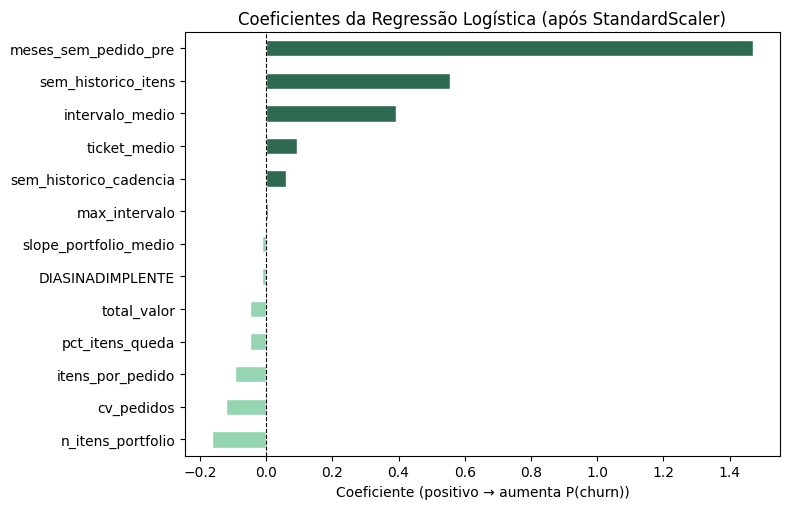

In [15]:
coefs = pd.Series(
    pipe_lr.named_steps["model"].coef_[0],
    index=X_train_lr.columns,
).sort_values()

cores = [VERDE[6] if v > 0 else VERDE[2] for v in coefs]

fig, ax = plt.subplots(figsize=(8, max(4, len(coefs) * 0.4)))
coefs.plot(kind="barh", ax=ax, color=cores, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Coeficientes da Regressão Logística (após StandardScaler)", fontsize=12)
ax.set_xlabel("Coeficiente (positivo → aumenta P(churn))")
plt.tight_layout()
plt.show()

---
## Seção 6 — Comparação de Modelos Tree-Based

Protocolo único aplicado a todos os modelos:
1. **Dado:** todos treinam sobre `X_train_clean` (Caminho A). Sem `fillna(0)` em bloco.
2. **Teste:** `X_test_clean` / `y_test` tocados **uma única vez**, na avaliação final. Nunca em `fit`, `eval_set` ou early stopping.
3. **Rounds (XGBoost e LightGBM):** selecionados via `xgb.cv` / `lgb.cv` com StratifiedKFold 5 no treino, early stopping dentro dos folds. O modelo final é re-treinado no treino completo com `n_estimators` fixo — sem early stopping.

| Modelo | Característica |
|---|---|
| XGBoost | Boosting — rounds selecionados via CV |
| LightGBM | Boosting — rounds selecionados via CV |
| Random Forest | Bagging — sem early stopping |

In [16]:
import xgboost as xgb
from xgboost import XGBClassifier

# ── Selecionar n_rounds via CV no treino (sem tocar o teste) ──────────────
dtrain_xgb = xgb.DMatrix(X_train_clean, label=y_train)

params_xgb_cv = {
    "learning_rate"    : 0.05,
    "max_depth"        : 4,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "eval_metric"      : "aucpr",
    "seed"             : 42,
    "verbosity"        : 0,
}

cv_xgb = xgb.cv(
    params_xgb_cv,
    dtrain_xgb,
    num_boost_round       = 300,
    nfold                 = 5,
    stratified            = True,
    early_stopping_rounds = 20,
    verbose_eval          = False,
    seed                  = 42,
)

best_n_xgb = int(cv_xgb["test-aucpr-mean"].idxmax()) + 1
print(f"XGBoost — n_rounds via CV (5-fold, aucpr): {best_n_xgb}  (vs. 11 vazado)")

# ── Re-treinar no treino completo com n_estimators fixo, sem early stopping ──
xgb_clf = XGBClassifier(
    n_estimators     = best_n_xgb,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "aucpr",
    random_state     = 42,
    verbosity        = 0,
)
xgb_clf.fit(X_train_clean, y_train)

y_prob_xgb  = xgb_clf.predict_proba(X_test_clean)[:, 1]
auc_roc_xgb = roc_auc_score(y_test, y_prob_xgb)
auc_pr_xgb  = average_precision_score(y_test, y_prob_xgb)

print(f"XGBoost (n={best_n_xgb}, CV limpo)  —  AUC-ROC: {auc_roc_xgb:.4f}  |  AUC-PR: {auc_pr_xgb:.4f}")

XGBoost — n_rounds via CV (5-fold, aucpr): 37  (vs. 11 vazado)


XGBoost (n=37, CV limpo)  —  AUC-ROC: 0.8928  |  AUC-PR: 0.8639


In [17]:
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# ── Selecionar n_rounds via CV no treino ──────────────────────────────────
dtrain_lgb = lgb.Dataset(X_train_clean, label=y_train)

params_lgb_cv = {
    "learning_rate"    : 0.05,
    "max_depth"        : 4,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "metric"           : "average_precision",
    "verbose"          : -1,
    "seed"             : 42,
}

cv_lgb = lgb.cv(
    params_lgb_cv,
    dtrain_lgb,
    num_boost_round = 300,
    nfold           = 5,
    stratified      = True,
    callbacks       = [early_stopping(20), log_evaluation(-1)],
    seed            = 42,
)

metric_key  = [k for k in cv_lgb if k.endswith("-mean")][0]
best_n_lgb  = int(np.argmax(cv_lgb[metric_key])) + 1
print(f"LightGBM — n_rounds via CV (5-fold, average_precision): {best_n_lgb}")

# ── Re-treinar no treino completo com n_estimators fixo, sem early stopping ──
lgbm = LGBMClassifier(
    n_estimators     = best_n_lgb,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbose          = -1,
)
lgbm.fit(X_train_clean, y_train)

y_prob_lgbm  = lgbm.predict_proba(X_test_clean)[:, 1]
auc_roc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
auc_pr_lgbm  = average_precision_score(y_test, y_prob_lgbm)

print(f"LightGBM (n={best_n_lgb}, CV limpo)  —  AUC-ROC: {auc_roc_lgbm:.4f}  |  AUC-PR: {auc_pr_lgbm:.4f}")

Training until validation scores don't improve for 20 rounds


Early stopping, best iteration is:
[4]	valid's average_precision: 0.80665 + 0.0272918
LightGBM — n_rounds via CV (5-fold, average_precision): 4


LightGBM (n=4, CV limpo)  —  AUC-ROC: 0.8770  |  AUC-PR: 0.8386


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = None,
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = -1,
)
rf.fit(X_train_clean, y_train)

y_prob_rf  = rf.predict_proba(X_test_clean)[:, 1]
auc_roc_rf = roc_auc_score(y_test, y_prob_rf)
auc_pr_rf  = average_precision_score(y_test, y_prob_rf)

print(f"Random Forest  —  AUC-ROC: {auc_roc_rf:.4f}  |  AUC-PR: {auc_pr_rf:.4f}")

Random Forest  —  AUC-ROC: 0.8889  |  AUC-PR: 0.8527


In [19]:
# Tabela final da Seção 6 — escolher o vencedor dinamicamente (não hardcoded)
resultados = pd.DataFrame([
    {"Modelo": "DummyClassifier",    "AUC-ROC": auc_roc_dummy, "AUC-PR": auc_pr_dummy},
    {"Modelo": "LogisticRegression", "AUC-ROC": auc_roc_lr,    "AUC-PR": auc_pr_lr},
    {"Modelo": "XGBoost",            "AUC-ROC": auc_roc_xgb,   "AUC-PR": auc_pr_xgb},
    {"Modelo": "LightGBM",           "AUC-ROC": auc_roc_lgbm,  "AUC-PR": auc_pr_lgbm},
    {"Modelo": "Random Forest",      "AUC-ROC": auc_roc_rf,    "AUC-PR": auc_pr_rf},
]).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print("=== Comparação final — modelos default ===\n")
print(resultados.to_string(index=False, float_format="{:.4f}".format))

# Registro de modelos treinados — o resto do notebook consulta este dict em vez
# de assumir qual modelo venceu (correção jul/2026: antes Seções 7-10 usavam
# `lgbm` hardcoded, ignorando o resultado real desta comparação)
MODELOS_TREINADOS = {
    "DummyClassifier":    (dummy,   y_prob_dummy),
    "LogisticRegression": (pipe_lr, y_prob_lr),
    "XGBoost":            (xgb_clf, y_prob_xgb),
    "LightGBM":           (lgbm,    y_prob_lgbm),
    "Random Forest":      (rf,      y_prob_rf),
}

nome_vencedor = resultados.iloc[0]["Modelo"]
modelo_vencedor, y_prob_vencedor = MODELOS_TREINADOS[nome_vencedor]
auc_roc_vencedor = resultados.iloc[0]["AUC-ROC"]
auc_pr_vencedor  = resultados.iloc[0]["AUC-PR"]

print(f"\n→ Vencedor: {nome_vencedor}  →  segue para threshold (Seção 7) e tuning no Optuna (Seção 8)")

=== Comparação final — modelos default ===

            Modelo  AUC-ROC  AUC-PR
           XGBoost   0.8928  0.8639
LogisticRegression   0.8923  0.8662
     Random Forest   0.8889  0.8527
          LightGBM   0.8770  0.8386
   DummyClassifier   0.5000  0.4903

→ Vencedor: XGBoost  →  segue para threshold (Seção 7) e tuning no Optuna (Seção 8)


---
## Seção 7 — Threshold de Decisão

AUC-ROC e AUC-PR medem separação — **não dizem em qual ponto de corte operar**.
Esta seção escolhe o threshold que equilibra precisão e recall conforme o custo de negócio.

### Lógica de custo
| Erro | Consequência |
|---|---|
| Falso negativo (perdemos um churner) | Cliente abandona sem ação → perda de receita recorrente |
| Falso positivo (alarmamos cliente ativo) | Esforço de retenção desnecessário → custo operacional |

Em B2B com receita recorrente, **FN > FP em custo** → priorizamos recall → usamos **F2** (pesa recall 2× mais que precisão).
F1 é mostrado como referência para o caso de FN ≈ FP.

> **Pergunta em aberto:** confirmar com o cliente a proporção FN/FP antes de fixar o threshold em produção.

Threshold ótimo F1 : 0.244  →  F1=0.854  prec=0.812  rec=0.901
Threshold ótimo F2 : 0.154  →  F2=0.895  prec=0.743  rec=0.944


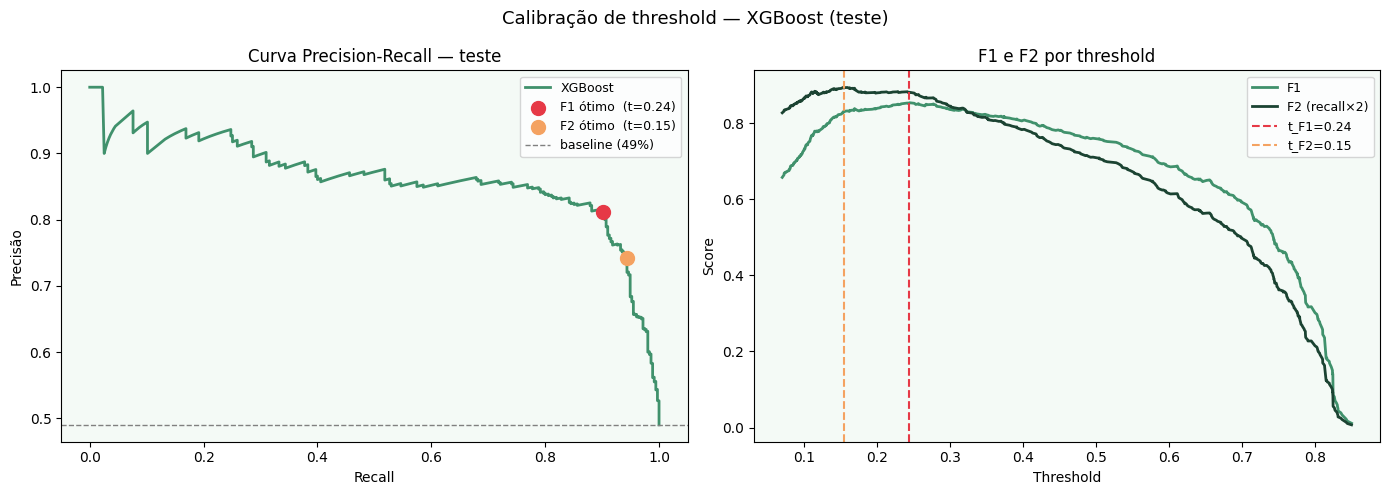

In [20]:
from sklearn.metrics import (
    precision_recall_curve, f1_score, fbeta_score,
    precision_score, recall_score, confusion_matrix,
)

# Usa o vencedor dinâmico da Seção 6
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob_vencedor)

f1_arr = []
f2_arr = []
for t in thresh_arr:
    pred = (y_prob_vencedor >= t).astype(int)
    f1_arr.append(f1_score(y_test, pred, zero_division=0))
    f2_arr.append(fbeta_score(y_test, pred, beta=2, zero_division=0))

f1_arr = np.array(f1_arr)
f2_arr = np.array(f2_arr)

idx_f1 = np.argmax(f1_arr)
idx_f2 = np.argmax(f2_arr)

THRESH_F1 = thresh_arr[idx_f1]
THRESH_F2 = thresh_arr[idx_f2]

print(f"Threshold ótimo F1 : {THRESH_F1:.3f}  →  F1={f1_arr[idx_f1]:.3f}  prec={prec_arr[idx_f1]:.3f}  rec={rec_arr[idx_f1]:.3f}")
print(f"Threshold ótimo F2 : {THRESH_F2:.3f}  →  F2={f2_arr[idx_f2]:.3f}  prec={prec_arr[idx_f2]:.3f}  rec={rec_arr[idx_f2]:.3f}")

# ── Curva PR com thresholds F1/F2 marcados ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_arr, prec_arr, color=VERDE[5], linewidth=2, label=nome_vencedor)
axes[0].scatter(rec_arr[idx_f1], prec_arr[idx_f1], color="#e63946", zorder=5, s=100,
                label=f"F1 ótimo  (t={THRESH_F1:.2f})")
axes[0].scatter(rec_arr[idx_f2], prec_arr[idx_f2], color="#f4a261", zorder=5, s=100,
                label=f"F2 ótimo  (t={THRESH_F2:.2f})")
axes[0].axhline(y_test.mean(), color="gray", ls="--", lw=1, label=f"baseline ({y_test.mean():.0%})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precisão")
axes[0].set_title("Curva Precision-Recall — teste")
axes[0].legend(fontsize=9)
axes[0].set_facecolor("#f4faf6")

# F1 e F2 em função do threshold
axes[1].plot(thresh_arr, f1_arr, color=VERDE[5], linewidth=2, label="F1")
axes[1].plot(thresh_arr, f2_arr, color=VERDE[7], linewidth=2, label="F2 (recall×2)")
axes[1].axvline(THRESH_F1, color="#e63946", ls="--", lw=1.5, label=f"t_F1={THRESH_F1:.2f}")
axes[1].axvline(THRESH_F2, color="#f4a261", ls="--", lw=1.5, label=f"t_F2={THRESH_F2:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("F1 e F2 por threshold")
axes[1].legend(fontsize=9)
axes[1].set_facecolor("#f4faf6")

plt.suptitle(f"Calibração de threshold — {nome_vencedor} (teste)", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Tabela de exploração: precisão, recall, F1, F2 e volume de alertas por threshold
thresholds_sweep = np.arange(0.20, 0.85, 0.05)

rows = []
for t in thresholds_sweep:
    pred = (y_prob_lgbm >= t).astype(int)
    rows.append({
        "threshold" : round(t, 2),
        "n_alertas" : int(pred.sum()),
        "precision" : round(precision_score(y_test, pred, zero_division=0), 3),
        "recall"    : round(recall_score(y_test, pred, zero_division=0), 3),
        "F1"        : round(f1_score(y_test, pred, zero_division=0), 3),
        "F2"        : round(fbeta_score(y_test, pred, beta=2, zero_division=0), 3),
    })

df_sweep = pd.DataFrame(rows)

# Marcação sem jinja2
df_sweep["ref"] = df_sweep["threshold"].apply(
    lambda t: "← F1 ótimo" if abs(t - round(THRESH_F1, 2)) < 0.026
    else ("← F2 ótimo" if abs(t - round(THRESH_F2, 2)) < 0.026 else "")
)

print("Precision / Recall / F1 / F2 por threshold\n")
print(df_sweep.to_string(index=False))

Precision / Recall / F1 / F2 por threshold

 threshold  n_alertas  precision  recall    F1    F2        ref
      0.20        724      0.490   1.000 0.658 0.828           
      0.25        724      0.490   1.000 0.658 0.828 ← F1 ótimo
      0.30        624      0.561   0.986 0.715 0.856           
      0.35        363      0.802   0.820 0.811 0.816           
      0.40        255      0.851   0.611 0.711 0.648           
      0.45        108      0.907   0.276 0.423 0.321           
      0.50          0      0.000   0.000 0.000 0.000           
      0.55          0      0.000   0.000 0.000 0.000           
      0.60          0      0.000   0.000 0.000 0.000           
      0.65          0      0.000   0.000 0.000 0.000           
      0.70          0      0.000   0.000 0.000 0.000           
      0.75          0      0.000   0.000 0.000 0.000           
      0.80          0      0.000   0.000 0.000 0.000           


=== Threshold escolhido: 0.154 (F2 ótimo) ===

  Precision : 0.743  — de cada alerta, 74% eram churn real
  Recall    : 0.944  — capturamos 94% de todos os churners
  F1        : 0.831
  F2        : 0.895
  Alertas   : 451 / 724  (62% da base)

=== Matriz de Confusão ===
               Predito Ativo  Predito Churn
  Real Ativo         253            116   ← falsos positivos (retenção desnecessária)
  Real Churn          20            335   ← falsos negativos (churners perdidos)


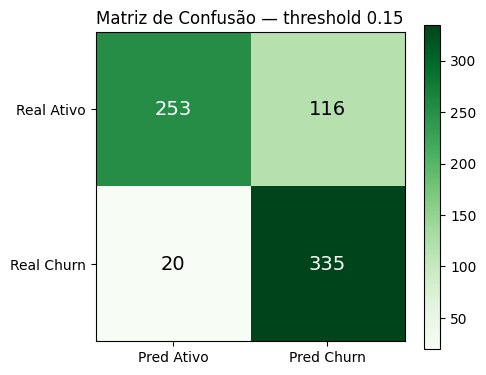


→ THRESHOLD = 0.154 definido para aplicação (Seção 10).
  Recalibrar após Optuna (Seção 8) se os scores mudarem.


In [22]:
# Threshold escolhido — F2 (FN mais caro que FP em B2B)
# Alterar para THRESH_F1 se o cliente confirmar custo simétrico
THRESHOLD = THRESH_F2

y_pred = (y_prob_vencedor >= THRESHOLD).astype(int)

prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
f2    = fbeta_score(y_test, y_pred, beta=2)
cm    = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print(f"=== Threshold escolhido: {THRESHOLD:.3f} (F2 ótimo) ===\n")
print(f"  Precision : {prec:.3f}  — de cada alerta, {prec:.0%} eram churn real")
print(f"  Recall    : {rec:.3f}  — capturamos {rec:.0%} de todos os churners")
print(f"  F1        : {f1:.3f}")
print(f"  F2        : {f2:.3f}")
print(f"  Alertas   : {y_pred.sum()} / {len(y_pred)}  ({y_pred.mean():.0%} da base)")

print(f"\n=== Matriz de Confusão ===")
print(f"               Predito Ativo  Predito Churn")
print(f"  Real Ativo        {tn:>4}           {fp:>4}   ← falsos positivos (retenção desnecessária)")
print(f"  Real Churn        {fn:>4}           {tp:>4}   ← falsos negativos (churners perdidos)")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Ativo", "Pred Churn"])
ax.set_yticklabels(["Real Ativo", "Real Churn"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title(f"Matriz de Confusão — threshold {THRESHOLD:.2f}", fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"\n→ THRESHOLD = {THRESHOLD:.3f} definido para aplicação (Seção 10).")
print(f"  Recalibrar após Optuna (Seção 8) se os scores mudarem.")

---
## Seção 8 — Tuning com Optuna

Otimiza o modelo vencedor da Seção 6 via busca de hiperparâmetros — dinamicamente:
se o vencedor for LightGBM ou XGBoost, tuning roda; caso contrário (Logistic
Regression ou Random Forest), esta seção é pulada (nunca tiveram tuning implementado).

**Objetivo:** maximizar AUC-PR na validação cruzada — métrica mais informativa que AUC-ROC quando há shift de distribuição entre treino (36%) e teste (49%).

**Estratégia:**
- StratifiedKFold(5) no conjunto de treino — sem tocar o teste
- `scale_pos_weight` entra como hiperparâmetro (a CV decide se ajuda e quanto)
- Early stopping por fold usando o conjunto de validação da própria CV
- Após o estudo: treinar modelo final no treino completo com os melhores parâmetros
- **Decisão tuned vs. default é automática:** só troca para o tunado se ele não piorar nem AUC-ROC nem AUC-PR — nunca um julgamento manual

In [23]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"NaN em X_train_clean: {X_train_clean.isna().sum().sum()}")
print(f"Modelo vencedor a tunar: {nome_vencedor}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Optuna implementado para os dois gradient boosting — os únicos que historicamente
# competem pela primeira posição. Se LogisticRegression ou Random Forest vencerem,
# pula tuning (nenhum dos dois tinha essa etapa antes desta correção também).
MODELOS_TUNAVEIS = {"LightGBM", "XGBoost"}


def objective(trial):
    if nome_vencedor == "LightGBM":
        params = {
            "learning_rate"    : trial.suggest_float("learning_rate",    0.01,  0.3,  log=True),
            "max_depth"        : trial.suggest_int(  "max_depth",        3,     8),
            "num_leaves"       : trial.suggest_int(  "num_leaves",       15,    127),
            "min_child_samples": trial.suggest_int(  "min_child_samples",10,    50),
            "subsample"        : trial.suggest_float("subsample",        0.6,   1.0),
            "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5,   1.0),
            "reg_alpha"        : trial.suggest_float("reg_alpha",        1e-8,  10.0, log=True),
            "reg_lambda"       : trial.suggest_float("reg_lambda",       1e-8,  10.0, log=True),
            "scale_pos_weight" : trial.suggest_float("scale_pos_weight", 0.5,   4.0),
            "n_estimators"     : 500,
            "random_state"     : 42,
            "verbose"          : -1,
        }
    elif nome_vencedor == "XGBoost":
        params = {
            "learning_rate"        : trial.suggest_float("learning_rate",    0.01,  0.3,  log=True),
            "max_depth"            : trial.suggest_int(  "max_depth",        3,     8),
            "min_child_weight"     : trial.suggest_int(  "min_child_weight", 1,     10),
            "subsample"            : trial.suggest_float("subsample",        0.6,   1.0),
            "colsample_bytree"     : trial.suggest_float("colsample_bytree", 0.5,   1.0),
            "reg_alpha"            : trial.suggest_float("reg_alpha",        1e-8,  10.0, log=True),
            "reg_lambda"           : trial.suggest_float("reg_lambda",       1e-8,  10.0, log=True),
            "scale_pos_weight"     : trial.suggest_float("scale_pos_weight", 0.5,   4.0),
            "n_estimators"         : 500,
            "random_state"         : 42,
            "verbosity"            : 0,
            "eval_metric"          : "aucpr",
            "early_stopping_rounds": 30,
        }
    else:
        raise ValueError(f"Optuna não implementado para {nome_vencedor}")

    fold_scores = []
    for tr_idx, val_idx in cv.split(X_train_clean, y_train):
        X_tr,  X_val = X_train_clean.iloc[tr_idx],  X_train_clean.iloc[val_idx]
        y_tr,  y_val = y_train.iloc[tr_idx],         y_train.iloc[val_idx]

        if nome_vencedor == "LightGBM":
            mdl = LGBMClassifier(**params)
            mdl.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[early_stopping(30, verbose=False), log_evaluation(-1)],
            )
        else:
            mdl = XGBClassifier(**params)
            mdl.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        prob = mdl.predict_proba(X_val)[:, 1]
        fold_scores.append(average_precision_score(y_val, prob))

    return np.mean(fold_scores)


if nome_vencedor in MODELOS_TUNAVEIS:
    print("Função objetivo definida.")
else:
    print(f"Optuna não implementado para '{nome_vencedor}' — Seção 8 vai usar o modelo default como está, sem tuning.")

NaN em X_train_clean: 0
Modelo vencedor a tunar: XGBoost
Função objetivo definida.


In [24]:
if nome_vencedor in MODELOS_TUNAVEIS:
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    best = study.best_trial
    print(f"\nMelhor AUC-PR (CV treino) : {best.value:.4f}")
    print(f"\nMelhores parâmetros:")
    for k, v in best.params.items():
        print(f"  {k:<22}: {v}")
else:
    study = None
    best = None
    print(f"Sem tuning para {nome_vencedor}.")

  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.82466:   0%|          | 0/100 [00:20<?, ?it/s]

Best trial: 0. Best value: 0.82466:   1%|          | 1/100 [00:20<33:22, 20.22s/it]

Best trial: 0. Best value: 0.82466:   1%|          | 1/100 [00:32<33:22, 20.22s/it]

Best trial: 0. Best value: 0.82466:   2%|▏         | 2/100 [00:32<25:23, 15.55s/it]

...

Best trial: 90. Best value: 0.855155:  99%|█████████▉| 99/100 [08:18<00:02,  2.18s/it]

Best trial: 90. Best value: 0.855155:  99%|█████████▉| 99/100 [08:20<00:02,  2.18s/it]

Best trial: 90. Best value: 0.855155: 100%|██████████| 100/100 [08:20<00:00,  2.10s/it]

Best trial: 90. Best value: 0.855155: 100%|██████████| 100/100 [08:20<00:00,  5.01s/it]


Melhor AUC-PR (CV treino) : 0.8552

Melhores parâmetros:
  learning_rate         : 0.14582428573505837
  max_depth             : 7
  min_child_weight      : 7
  subsample             : 0.7504709480626889
  colsample_bytree      : 0.630255993834703
  reg_alpha             : 8.94621819192147e-05
  reg_lambda            : 9.650603487095456e-08
  scale_pos_weight      : 1.2218295548956895


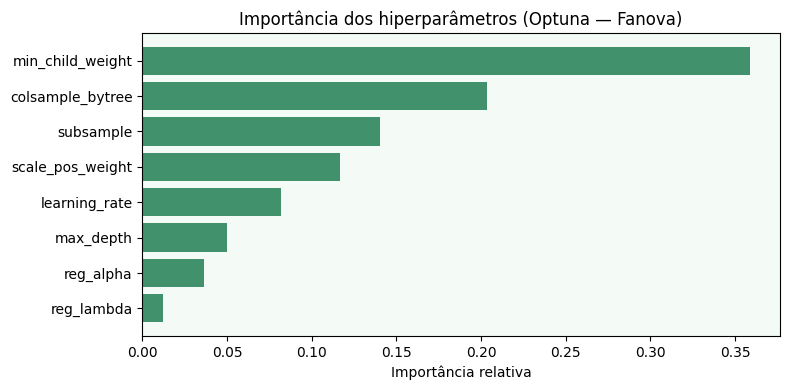

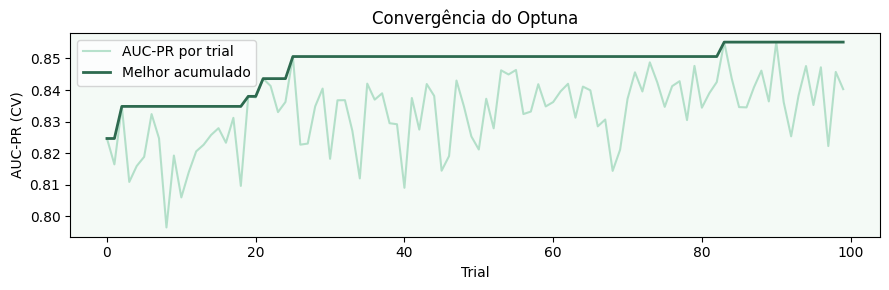

In [25]:
if study is not None:
    # Importância de cada hiperparâmetro no estudo
    param_imp = optuna.importance.get_param_importances(study)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(list(param_imp.keys())[::-1], list(param_imp.values())[::-1], color=VERDE[5])
    ax.set_xlabel("Importância relativa")
    ax.set_title("Importância dos hiperparâmetros (Optuna — Fanova)")
    ax.set_facecolor("#f4faf6")
    plt.tight_layout()
    plt.show()

    # Curva de convergência
    valores = [t.value for t in study.trials]
    melhor_acum = np.maximum.accumulate(valores)

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(valores,      color=VERDE[3], alpha=0.5, label="AUC-PR por trial")
    ax.plot(melhor_acum,  color=VERDE[6], linewidth=2, label="Melhor acumulado")
    ax.set_xlabel("Trial")
    ax.set_ylabel("AUC-PR (CV)")
    ax.set_title("Convergência do Optuna")
    ax.legend()
    ax.set_facecolor("#f4faf6")
    plt.tight_layout()
    plt.show()
else:
    print("Sem estudo Optuna para este modelo — nada a exibir.")

In [26]:
if study is not None:
    print(f"Melhor trial : {study.best_trial.number}")
    print(f"Melhor valor : {study.best_value:.4f}")
else:
    print("Sem estudo Optuna para este modelo.")

Melhor trial : 90
Melhor valor : 0.8552


In [27]:
# Modelo final: treina a versão tunada (se aplicável) e decide automaticamente
# se ela substitui o default — regra: só troca se NÃO piorar nenhuma das duas
# métricas (mesmo espírito das decisões anteriores, agora sem julgamento manual)
if nome_vencedor in MODELOS_TUNAVEIS and study is not None:
    if nome_vencedor == "LightGBM":
        best_params  = {**best.params, "n_estimators": 500, "random_state": 42, "verbose": -1}
        modelo_tuned = LGBMClassifier(**best_params)
    else:
        best_params  = {**best.params, "n_estimators": 500, "random_state": 42, "verbosity": 0}
        modelo_tuned = XGBClassifier(**best_params)

    modelo_tuned.fit(X_train_clean, y_train)

    y_prob_tuned  = modelo_tuned.predict_proba(X_test_clean)[:, 1]
    auc_roc_tuned = roc_auc_score(y_test, y_prob_tuned)
    auc_pr_tuned  = average_precision_score(y_test, y_prob_tuned)

    print("=== Comparação: default vs tuned ===\n")
    print(f"{'Modelo':<28} {'AUC-ROC':>8}  {'AUC-PR':>8}")
    print("-" * 48)
    print(f"{nome_vencedor + ' default':<28} {auc_roc_vencedor:>8.4f}  {auc_pr_vencedor:>8.4f}")
    print(f"{nome_vencedor + ' tuned':<28} {auc_roc_tuned:>8.4f}  {auc_pr_tuned:>8.4f}")
    delta_roc = auc_roc_tuned - auc_roc_vencedor
    delta_pr  = auc_pr_tuned  - auc_pr_vencedor
    print(f"\nGanho tuning  —  ROC: {delta_roc:+.4f}  |  PR: {delta_pr:+.4f}")

    usar_tuned = (auc_roc_tuned >= auc_roc_vencedor) and (auc_pr_tuned >= auc_pr_vencedor)

    if usar_tuned:
        modelo_final, y_prob_final, nome_final = modelo_tuned, y_prob_tuned, f"{nome_vencedor} (tuned)"
        print(f"\n→ Tuning não piorou nenhuma métrica — modelo final: {nome_final}")
    else:
        modelo_final, y_prob_final, nome_final = modelo_vencedor, y_prob_vencedor, f"{nome_vencedor} (default)"
        print(f"\n→ Tuning piorou ao menos uma métrica — modelo final: {nome_final}")
else:
    modelo_final, y_prob_final, nome_final = modelo_vencedor, y_prob_vencedor, f"{nome_vencedor} (default)"
    print(f"Optuna não aplicável a {nome_vencedor} — modelo final: {nome_final}")

auc_roc_final = roc_auc_score(y_test, y_prob_final)
auc_pr_final  = average_precision_score(y_test, y_prob_final)
print(f"\nModelo final definitivo: {nome_final}  —  AUC-ROC: {auc_roc_final:.4f}  |  AUC-PR: {auc_pr_final:.4f}")

=== Comparação: default vs tuned ===

Modelo                        AUC-ROC    AUC-PR
------------------------------------------------
XGBoost default                0.8928    0.8639
XGBoost tuned                  0.8793    0.8422

Ganho tuning  —  ROC: -0.0134  |  PR: -0.0217

→ Tuning piorou ao menos uma métrica — modelo final: XGBoost (default)

Modelo final definitivo: XGBoost (default)  —  AUC-ROC: 0.8928  |  AUC-PR: 0.8639


---
### Decisão: modelo final = vencedor da Seção 6, tunado ou não

A regra é automática (ver código acima): o modelo tunado só substitui o default se
não piorar nenhuma das duas métricas (AUC-ROC e AUC-PR). Os números exatos desta
execução aparecem no output da célula anterior — não fixados aqui em markdown para
não ficarem desatualizados a cada re-treino (isso já aconteceu antes: números antigos
citavam LightGBM como vencedor fixo, o que deixou de ser verdade depois da correção
de vazamento de jul/2026 nas features de item).

**Modelo final para as Seções 9 e 10A:** `modelo_final` — nome exibido em `nome_final`,
probabilidades em `y_prob_final`, threshold em `THRESHOLD` (definido na Seção 7 a
partir do vencedor pré-tuning).

---
## Seção 9 — SHAP

Explica o modelo — quais features realmente importam e como cada uma afeta a previsão para cada cliente individualmente.

| Visualização | O que responde |
|---|---|
| **Beeswarm** | Quais features o modelo usou mais? Em que direção? |
| **Waterfall** | Por que esse cliente específico foi marcado como churn? |
| **Dependence plot** | Como `meses_sem_pedido_pre` interage com outras features? |

No final desta seção: **decisão definitiva** sobre as hipóteses de remoção de features das Seções 2/3.

In [28]:
# Alias para células de SHAP (compatibilidade com nomes anteriores)
X_test_xgb = X_test_clean

In [29]:
import shap

# Explainer genérico — funciona para os modelos tree-based (LightGBM/XGBoost/
# Random Forest). TreeExplainer sem dataset de background usa
# feature_perturbation="tree_path_dependent" (não precisa de dado auxiliar e
# evita um NotImplementedError do XGBoost com o modo "interventional" default
# do despacho automático shap.Explainer). LogisticRegression usa um Pipeline
# (scaler + modelo) que não é diretamente suportado aqui — os coeficientes da
# Seção 5 já cobrem a interpretabilidade nesse caso.
if nome_vencedor == "LogisticRegression":
    print("SHAP não implementado para o pipeline de LogisticRegression nesta seção.")
    print("Os coeficientes da Seção 5 já dão a interpretabilidade equivalente.")
    shap_vals = None
else:
    explainer = shap.TreeExplainer(modelo_final)
    shap_vals = explainer(X_test_xgb)
    print(f"SHAP values computados: {shap_vals.values.shape}")
    print(f"Features: {list(X_test_xgb.columns)}")

SHAP values computados: (724, 19)
Features: ['n_meses_ativos', 'total_pedidos', 'total_valor', 'media_pedidos_mes', 'ticket_medio', 'itens_por_pedido', 'categoria_pedido', 'cv_pedidos', 'meses_sem_pedido_pre', 'intervalo_medio', 'max_intervalo', 'n_intervalos', 'categoria_cliente', 'slope_portfolio_medio', 'pct_itens_queda', 'n_itens_portfolio', 'DIASINADIMPLENTE', 'sem_historico_cadencia', 'sem_historico_itens']


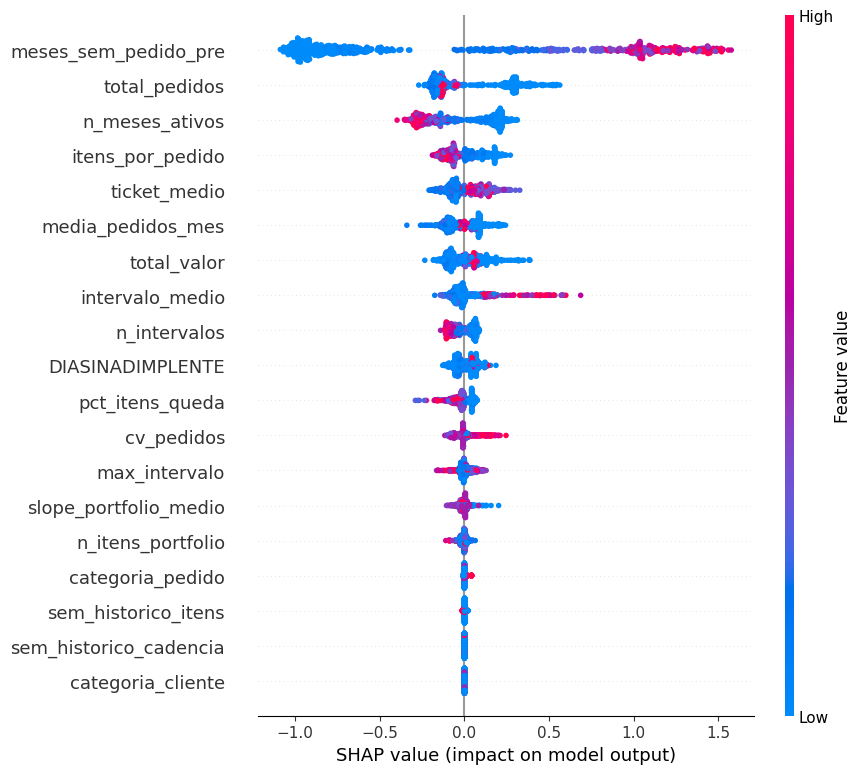

In [30]:
# 9.1 — Beeswarm: importância global de todas as features
if shap_vals is not None:
    shap.plots.beeswarm(shap_vals, max_display=20, show=True)
else:
    print("Sem SHAP para este modelo.")

Caso 1 — Verdadeiro Positivo (cliente 1125, score=0.849)


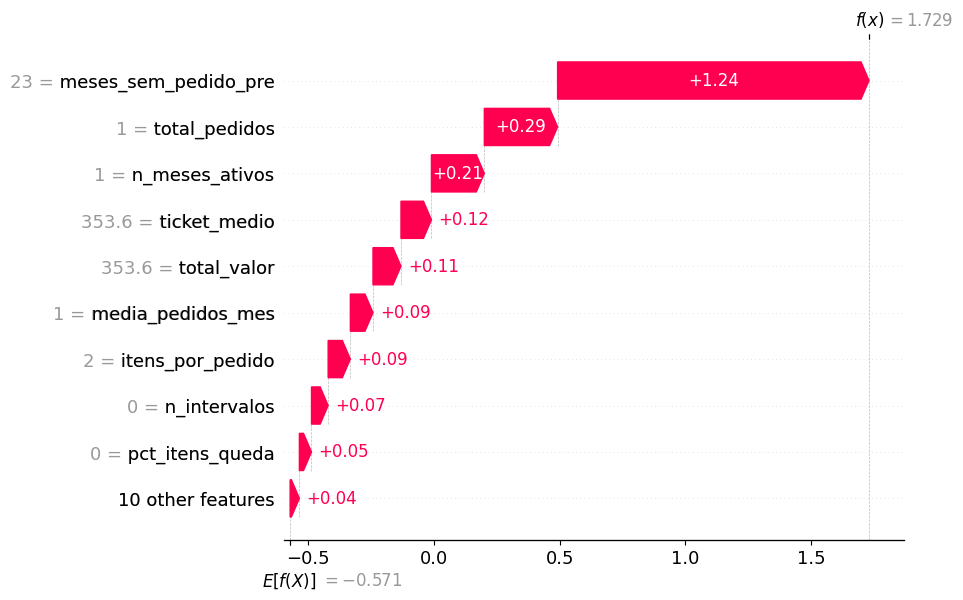


Caso 2 — Falso Positivo (cliente 673, score=0.831)


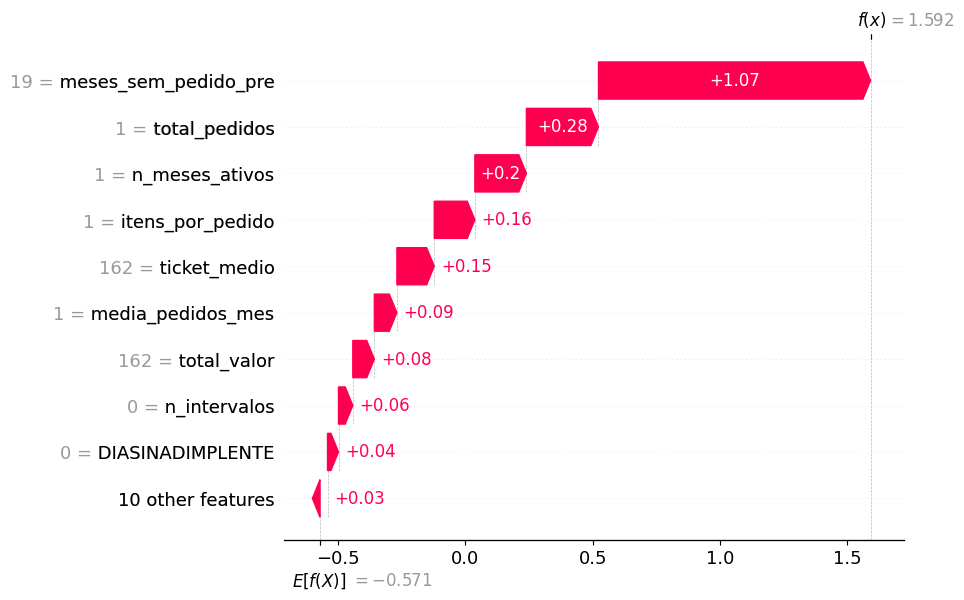

In [31]:
# 9.2 — Waterfall: por que o modelo marcou esse cliente como churn?
# Mostra os dois casos mais interessantes: o churn mais óbvio e o maior erro do modelo.
if shap_vals is not None:
    y_pred_final = (y_prob_final >= THRESHOLD).astype(int)

    # Caso 1: verdadeiro positivo com maior score (o modelo estava mais certo)
    tp_mask  = (y_test.values == 1) & (y_pred_final == 1)
    idx_tp   = np.where(tp_mask)[0][np.argmax(y_prob_final[tp_mask])]

    # Caso 2: falso positivo com maior score (o modelo errou com mais confiança)
    fp_mask  = (y_test.values == 0) & (y_pred_final == 1)
    idx_fp   = np.where(fp_mask)[0][np.argmax(y_prob_final[fp_mask])]

    cliente_tp = df_teste.iloc[idx_tp]["CLIENTE"] if "CLIENTE" in df_teste.columns else idx_tp
    cliente_fp = df_teste.iloc[idx_fp]["CLIENTE"] if "CLIENTE" in df_teste.columns else idx_fp

    print(f"Caso 1 — Verdadeiro Positivo (cliente {cliente_tp}, score={y_prob_final[idx_tp]:.3f})")
    shap.plots.waterfall(shap_vals[idx_tp], show=True)

    print(f"\nCaso 2 — Falso Positivo (cliente {cliente_fp}, score={y_prob_final[idx_fp]:.3f})")
    shap.plots.waterfall(shap_vals[idx_fp], show=True)
else:
    print("Sem SHAP para este modelo.")

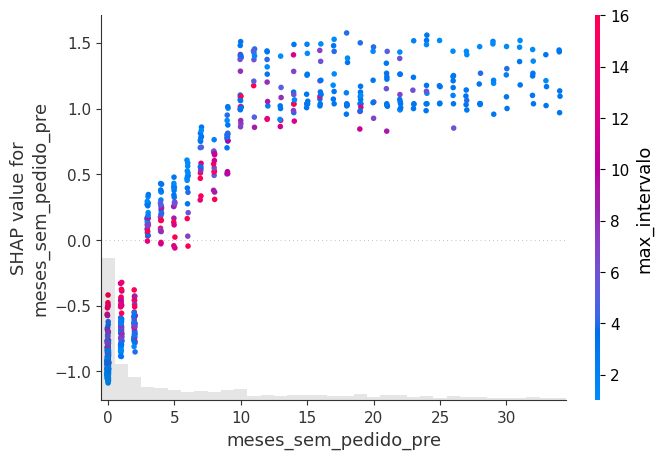

In [32]:
# 9.3 — Dependence plot: meses_sem_pedido_pre (feature mais forte, Pearson ~0.62)
if shap_vals is not None:
    shap.plots.scatter(shap_vals[:, "meses_sem_pedido_pre"], color=shap_vals, show=True)
else:
    print("Sem SHAP para este modelo.")

In [33]:
# 9.4 — Decisão sobre hipóteses de remoção de features
# Compara as hipóteses das Seções 2/3 com o que o SHAP realmente mostrou.
if shap_vals is not None:
    mean_abs_shap = pd.Series(
        np.abs(shap_vals.values).mean(axis=0),
        index=X_test_xgb.columns,
    ).sort_values(ascending=False)

    print("Importância SHAP média (|SHAP|) — todas as features:\n")
    print(f"{'Feature':<25} {'|SHAP| médio':>12}  {'Hipótese Seção 2/3':>20}")
    print("=" * 62)
    for feat, val in mean_abs_shap.items():
        hipotese = ""
        if feat in HIPOTESES_BAIXO_SINAL:
            hipotese = "baixo sinal"
        if feat in HIPOTESES_REDUNDANCIA:
            hipotese = hipotese + " + redundante" if hipotese else "redundante"
        print(f"{feat:<25} {val:>12.4f}  {hipotese:>20}")

    SHAP_THRESHOLD = 0.01
    remover_shap   = mean_abs_shap[mean_abs_shap < SHAP_THRESHOLD].index.tolist()

    print(f"\n=== Decisão final ===")
    print(f"Features com |SHAP| < {SHAP_THRESHOLD} (realmente irrelevantes):")
    print(f"  {remover_shap if remover_shap else 'Nenhuma — manter todas'}")
    print(f"\nHipóteses de baixo sinal (Seção 2): {HIPOTESES_BAIXO_SINAL}")
    print(f"Hipóteses de redundância (Seção 3): {HIPOTESES_REDUNDANCIA}")
    print(f"\n→ Comparar as listas: se uma hipótese NÃO aparece em remover_shap,")
    print(f"  o SHAP desconfirmou a hipótese — manter a feature no modelo.")
else:
    print("Sem SHAP para este modelo — decisão de features não avaliada nesta execução.")

Importância SHAP média (|SHAP|) — todas as features:

Feature                   |SHAP| médio    Hipótese Seção 2/3
meses_sem_pedido_pre            0.8502                      
total_pedidos                   0.2003                      
n_meses_ativos                  0.1972            redundante
itens_por_pedido                0.0923                      
ticket_medio                    0.0833           baixo sinal
media_pedidos_mes               0.0830            redundante
total_valor                     0.0827            redundante
intervalo_medio                 0.0756                      
n_intervalos                    0.0594            redundante
DIASINADIMPLENTE                0.0490                      
pct_itens_queda                 0.0419                      
cv_pedidos                      0.0408                      
max_intervalo                   0.0274            redundante
slope_portfolio_medio           0.0190                      
n_itens_portfolio              

---

## Seção 10 — Calibração do modelo (parte do treino)

A calibração de probabilidade é ajustada (`fit`) sobre o conjunto de treino — por isso fica aqui, junto com o resto do pipeline de treino, e não no scoring mensal.

A partir daqui o notebook produz os dois artefatos que serão persistidos em disco (`data/processed/modelo_churn.pkl`) para uso pelo pipeline de inferência: o modelo vencedor treinado (`modelo_final`, dinâmico — não necessariamente LightGBM) e o calibrador escolhido (`calibrador`).

**A aplicação em si — receita anual, ranking por valor em risco, geração da lista de alertas — foi movida para `scripts/scoring_mensal.py`.** Esse é o pipeline que precisa rodar todo mês, sem depender deste notebook estar aberto.

### 10A — Calibração de Probabilidade

In [34]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# cv=5 re-treina o modelo final internamente em cada fold — teste nunca é tocado
cal_isotonic = CalibratedClassifierCV(modelo_final, method="isotonic", cv=5)
cal_sigmoid  = CalibratedClassifierCV(modelo_final, method="sigmoid",  cv=5)

cal_isotonic.fit(X_train_clean, y_train)
cal_sigmoid.fit(X_train_clean,  y_train)

p_bruta    = y_prob_final
p_isotonic = cal_isotonic.predict_proba(X_test_clean)[:, 1]
p_sigmoid  = cal_sigmoid.predict_proba(X_test_clean)[:, 1]

bs_bruta    = brier_score_loss(y_test, p_bruta)
bs_isotonic = brier_score_loss(y_test, p_isotonic)
bs_sigmoid  = brier_score_loss(y_test, p_sigmoid)

print(f"Brier score — bruto    : {bs_bruta:.4f}")
print(f"Brier score — isotonic : {bs_isotonic:.4f}")
print(f"Brier score — sigmoid  : {bs_sigmoid:.4f}")
print(f"\nMelhor: {'isotonic' if bs_isotonic <= bs_sigmoid else 'sigmoid'}")

Brier score — bruto    : 0.1481
Brier score — isotonic : 0.1422
Brier score — sigmoid  : 0.1494

Melhor: isotonic


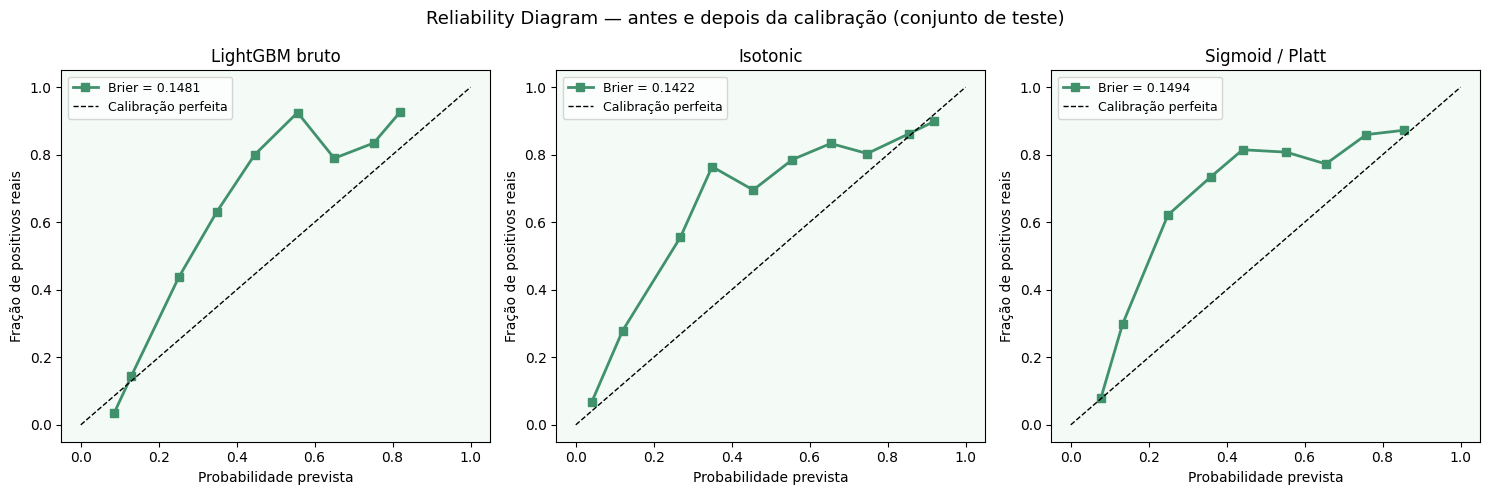

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (probs, nome, bs) in zip(axes, [
    (p_bruta,    "LightGBM bruto",  bs_bruta),
    (p_isotonic, "Isotonic",        bs_isotonic),
    (p_sigmoid,  "Sigmoid / Platt", bs_sigmoid),
]):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", color=VERDE[5], lw=2,
            label=f"Brier = {bs:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Calibração perfeita")
    ax.set_title(nome, fontsize=12)
    ax.set_xlabel("Probabilidade prevista")
    ax.set_ylabel("Fração de positivos reais")
    ax.legend(fontsize=9)
    ax.set_facecolor("#f4faf6")

plt.suptitle("Reliability Diagram — antes e depois da calibração (conjunto de teste)", fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
# Modelo calibrado oficial — menor Brier score
if bs_isotonic <= bs_sigmoid:
    calibrador = cal_isotonic
    METODO_CAL = "isotonic"
else:
    calibrador = cal_sigmoid
    METODO_CAL = "sigmoid"

y_prob_calibrada = calibrador.predict_proba(X_test_clean)[:, 1]

print(f"Calibrador escolhido : {METODO_CAL}")
print(f"Brier score final    : {brier_score_loss(y_test, y_prob_calibrada):.4f}")
print(f"\nEstatísticas das probabilidades calibradas:")
print(f"  min  : {y_prob_calibrada.min():.3f}")
print(f"  p25  : {pd.Series(y_prob_calibrada).quantile(0.25):.3f}")
print(f"  med  : {pd.Series(y_prob_calibrada).median():.3f}")
print(f"  p75  : {pd.Series(y_prob_calibrada).quantile(0.75):.3f}")
print(f"  max  : {y_prob_calibrada.max():.3f}")

Calibrador escolhido : isotonic
Brier score final    : 0.1422

Estatísticas das probabilidades calibradas:
  min  : 0.000
  p25  : 0.061
  med  : 0.324
  p75  : 0.756
  max  : 0.943


---
### Passo 1 — Persistir modelo + calibrador

Fim do pipeline de treino. A partir daqui, `scripts/scoring_mensal.py` carrega este
arquivo em vez de depender deste notebook estar aberto — é o que separa
"treinar" (raro, com revisão humana) de "aplicar" (mensal, sem supervisão).

Guardamos três coisas: o modelo LightGBM treinado (`lgbm`), o calibrador escolhido
(`calibrador`, isotonic) e a lista exata de features na ordem que o modelo espera
(`X_train_clean.columns`) — sem isso, o script de scoring não saberia montar o `X`
corretamente a partir de dado novo.

In [37]:
import pickle

artefatos = {
    "modelo": modelo_final,
    "modelo_nome": nome_final,
    "calibrador": calibrador,
    "features": list(X_train_clean.columns),
}

modelo_path = PROCESSED_DIR / "modelo_churn.pkl"
with open(modelo_path, "wb") as f:
    pickle.dump(artefatos, f)

print(f"Salvo em: {modelo_path}")
print(f"Modelo final: {nome_final}")
print(f"Features ({len(artefatos['features'])}): {artefatos['features']}")
print(f"Calibrador: {METODO_CAL}")

Salvo em: C:\Users\carva\OneDrive\Área de Trabalho\central_eto\data\processed\modelo_churn.pkl
Modelo final: XGBoost (default)
Features (19): ['n_meses_ativos', 'total_pedidos', 'total_valor', 'media_pedidos_mes', 'ticket_medio', 'itens_por_pedido', 'categoria_pedido', 'cv_pedidos', 'meses_sem_pedido_pre', 'intervalo_medio', 'max_intervalo', 'n_intervalos', 'categoria_cliente', 'slope_portfolio_medio', 'pct_itens_queda', 'n_itens_portfolio', 'DIASINADIMPLENTE', 'sem_historico_cadencia', 'sem_historico_itens']
Calibrador: isotonic
